In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8-white') 

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 18    
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 24

# [ADDED] 设置边框和刻度的线宽
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

# --- 1. 加载数据 (已更新) ---
data_filename = 'result/data.csv'  # <-- 更改了文件名
try:
    # 使用 \s+ (正则表达式) 来匹配一个或多个空格/制表符
    # 移除了 index_col=0，因为新文件的第一列是 'N'
    df = pd.read_csv(data_filename, sep=r'\s+') # <-- 移除了 index_col=0
    print(f"成功从 '{data_filename}' 加载数据。")
    print("数据前5行:")
    print(df.head())
except FileNotFoundError:
    print(f"错误: 文件 '{data_filename}' 未找到。请确保文件路径正确。")
    exit()
except Exception as e:
    print(f"读取文件时发生错误: {e}")
    exit()

# --- 2. 数据准备 (与之前相同) ---

# (a) 准备 p_c(N) - p_c 数据
# 假设 N=10^6 的数据点是热力学极限 p_c 的最佳估计
pc_inf_gscc = df[df['N'] == 1000000]['pc_gscc'].values[0]
pc_inf_gout = df[df['N'] == 1000000]['pc_gout'].values[0]
pc_inf_gin = df[df['N'] == 1000000]['pc_gin'].values[0]

# 计算 p_c(N) - p_c。
# 排除 N=10^6 的点，因为它减去自己会得到0，无法在log图上显示
df_pc = df[df['N'] < 1000000].copy()
df_pc['delta_pc_gscc'] = df_pc['pc_gscc'] - pc_inf_gscc
df_pc['delta_pc_gout'] = df_pc['pc_gout'] - pc_inf_gout
df_pc['delta_pc_gin'] = df_pc['pc_gin'] - pc_inf_gin

# 提取 x 和 y 数据用于绘图
x_N_pc = df_pc['N']
x_N_full = df['N']

# (b) 准备 R (渗流强度) 数据
y_R_gscc = df['R_gscc_at_pc']
y_R_gout = df['R_gout_at_pc']
y_R_gin = df['R_gin_at_pc']

# (c) 准备 chi (磁化率) 数据
y_chi_gscc = df['chi_peak_gscc']
y_chi_gout = df['chi_peak_gout']
y_chi_gin = df['chi_peak_gin']

# --- 3. 拟合函数 (与之前相同) ---
# 在双对数空间中进行线性拟合
def fit_power_law(x, y):
    # 确保所有y值都是正数，以便取对数
    valid_indices = (y > 0)
    if not np.any(valid_indices):
        print("警告: 无法拟合，因为没有正数数据点。")
        return np.array([]), np.array([]), 0
        
    x_fit_data = x[valid_indices]
    y_fit_data = y[valid_indices]

    log_x = np.log(x_fit_data)
    log_y = np.log(y_fit_data)
    
    # 检查是否有足够的数据点来拟合
    if len(log_x) < 2:
        print("警告: 数据点不足 (少于2个)，无法进行幂律拟合。")
        return np.array([]), np.array([]), 0

    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    # 创建拟合线
    x_fit_line = np.geomspace(x.min(), x.max(), 100)
    y_fit_line = np.exp(slope * np.log(x_fit_line) + intercept)
    
    return x_fit_line, y_fit_line, slope

# --- 4. 绘图 (与之前相同) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- 图 (a): p_c(N) - p_c ---
# 仅绘制y值为正的点
ax1.scatter(x_N_pc[df_pc['delta_pc_gout'] > 0], df_pc['delta_pc_gout'][df_pc['delta_pc_gout'] > 0], marker='o', edgecolors='blue', label='HGOUT')
ax1.scatter(x_N_pc[df_pc['delta_pc_gin'] > 0], df_pc['delta_pc_gin'][df_pc['delta_pc_gin'] > 0], marker='s',edgecolors='orange', label='HGIN')
ax1.scatter(x_N_pc[df_pc['delta_pc_gscc'] > 0], df_pc['delta_pc_gscc'][df_pc['delta_pc_gscc'] > 0], marker='^', edgecolors='green', label='HGSCC')

# 增大图例字体大小

# 拟合线
x_fit, y_fit, slope = fit_power_law(x_N_pc, df_pc['delta_pc_gout'])
if x_fit.size > 0: ax1.plot(x_fit, y_fit, 'b--')
x_fit, y_fit, slope = fit_power_law(x_N_pc, df_pc['delta_pc_gin'])
if x_fit.size > 0: ax1.plot(x_fit, y_fit, '--', color='orange')
x_fit, y_fit, slope = fit_power_law(x_N_pc, df_pc['delta_pc_gscc'])
if x_fit.size > 0: ax1.plot(x_fit, y_fit, 'g--')

ax1.set_xscale('log')
ax1.set_yscale('log')
# ax1.set_xlabel('Network size $N$')
ax1.set_ylabel('$p_c(N) - p_c$')
ax1.legend(fontsize=18, frameon=True)
# ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, fontsize=16, va='top')

# --- 图 (b): Percolation strength R ---
ax2.scatter(x_N_full, y_R_gout, marker='o',  edgecolors='blue')
ax2.scatter(x_N_full, y_R_gin, marker='s',  edgecolors='orange')
ax2.scatter(x_N_full, y_R_gscc, marker='^', edgecolors='green')

# 拟合线
x_fit, y_fit, slope = fit_power_law(x_N_full, y_R_gout)
if x_fit.size > 0: ax2.plot(x_fit, y_fit, 'b--')
x_fit, y_fit, slope = fit_power_law(x_N_full, y_R_gin)
if x_fit.size > 0: ax2.plot(x_fit, y_fit, '--', color='orange')
x_fit, y_fit, slope = fit_power_law(x_N_full, y_R_gscc)
if x_fit.size > 0: ax2.plot(x_fit, y_fit, 'g--')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Network size $N$')
ax2.set_ylabel('$R(p_c)$')
ax2.legend(fontsize=9)
# ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes, fontsize=16, va='top')

# --- 图 (c): Susceptibility chi ---
ax3.scatter(x_N_full, y_chi_gout, marker='o', edgecolors='blue')
ax3.scatter(x_N_full, y_chi_gin, marker='s',  edgecolors='orange')
ax3.scatter(x_N_full, y_chi_gscc, marker='^',  edgecolors='green')

# 拟合线
x_fit, y_fit, slope = fit_power_law(x_N_full, y_chi_gout)
if x_fit.size > 0: ax3.plot(x_fit, y_fit, 'b--')
x_fit, y_fit, slope = fit_power_law(x_N_full, y_chi_gin)
if x_fit.size > 0: ax3.plot(x_fit, y_fit, '--', color='orange')
x_fit, y_fit, slope = fit_power_law(x_N_full, y_chi_gscc)
if x_fit.size > 0: ax3.plot(x_fit, y_fit, 'g--')

ax3.set_xscale('log')
ax3.set_yscale('log')
# ax3.set_xlabel('Network size $N$')
ax3.set_ylabel('$\chi_{peak}$')
ax3.legend(fontsize=9)
# ax3.text(0.05, 0.95, '(c)', transform=ax3.transAxes, fontsize=16, va='top')


# --- 5. 保存 ---
plt.tight_layout()
plt.savefig('finite_size_scaling_plot.pdf', dpi=300)
plt.savefig('finite_size_scaling_plot.png', dpi=300)

print("FSS 图像已保存为 'finite_size_scaling_plot.pdf' 和 'finite_size_scaling_plot.png'")
# plt.show() # 在VM环境中注释掉plt.show()

File saved: comparison_clean.pdf


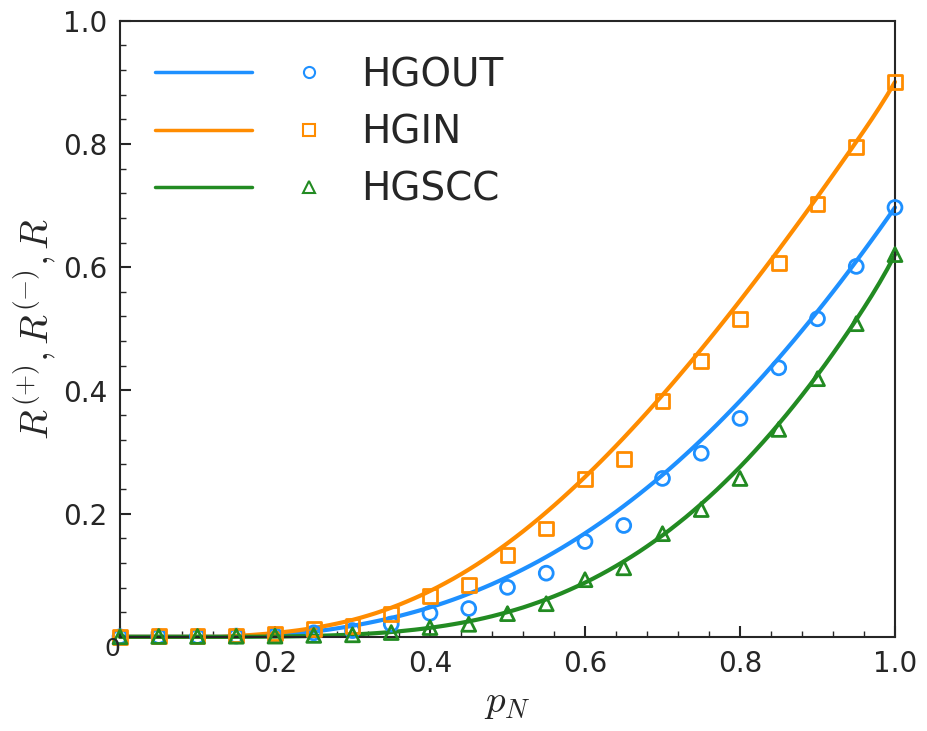

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 18
plt.rcParams['axes.labelsize'] = 28
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 26
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

filename = 'percolation.txt'

try:
    df = pd.read_csv(filename, delimiter=',')

    p_values_to_show = np.arange(0.0, 1.01, 0.05)
    df_scatter = df[df['node_survival'].round(2).isin(p_values_to_show.round(2))]

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.plot(df['node_survival'], df['mp_gout'], color='dodgerblue', linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df['node_survival'], df['mp_gin'],  color='darkorange', linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df['node_survival'], df['mp_gscc'], color='forestgreen', linestyle='-', linewidth=3, zorder=2, clip_on=False)

    ax.scatter(df_scatter['node_survival'], df_scatter['sim_gout'], facecolors='none', edgecolors='dodgerblue', marker='o', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter['node_survival'], df_scatter['sim_gin'],  facecolors='none', edgecolors='darkorange', marker='s', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter['node_survival'], df_scatter['sim_gscc'], facecolors='none', edgecolors='forestgreen', marker='^', s=100, linewidth=2, zorder=3, clip_on=False)

    ax.set_xlabel('$p_N$', fontstyle='italic')
    ax.set_ylabel(r'$R^{(+)}\mathrm{,}\,R^{(-)}\mathrm{,}\,R$')

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticklabels(['', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_yticklabels(['', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.text(0, 0, '0', horizontalalignment='right', verticalalignment='top', transform=ax.transAxes)

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(which='major', direction='in', length=8)
    ax.tick_params(which='minor', direction='in', length=4)

    line_handles = [
        Line2D([0], [0], color='dodgerblue', lw=2.5),
        Line2D([0], [0], color='darkorange', lw=2.5),
        Line2D([0], [0], color='forestgreen', lw=2.5)
    ]
    marker_handles = [
        Line2D([0], [0], color='dodgerblue', marker='o', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='darkorange', marker='s', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='forestgreen', marker='^', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5)
    ]

    handles = [line_handles[0], line_handles[1], line_handles[2], marker_handles[0], marker_handles[1], marker_handles[2]]
    labels = ['', '', '', 'HGOUT', 'HGIN', 'HGSCC']

    ax.legend(handles, labels,
              loc='upper left',
              ncol=2,
              frameon=False,
              fontsize=28,
              handlelength=2.5,
              handletextpad=0.1,
              columnspacing=0.1)

    output_filename = 'comparison_clean.pdf'
    plt.savefig(output_filename, bbox_inches='tight')

    print(f"File saved: {output_filename}")

except Exception as e:
    print(f"Error: {e}")

Plot saved as ijo_joint_topology.svg


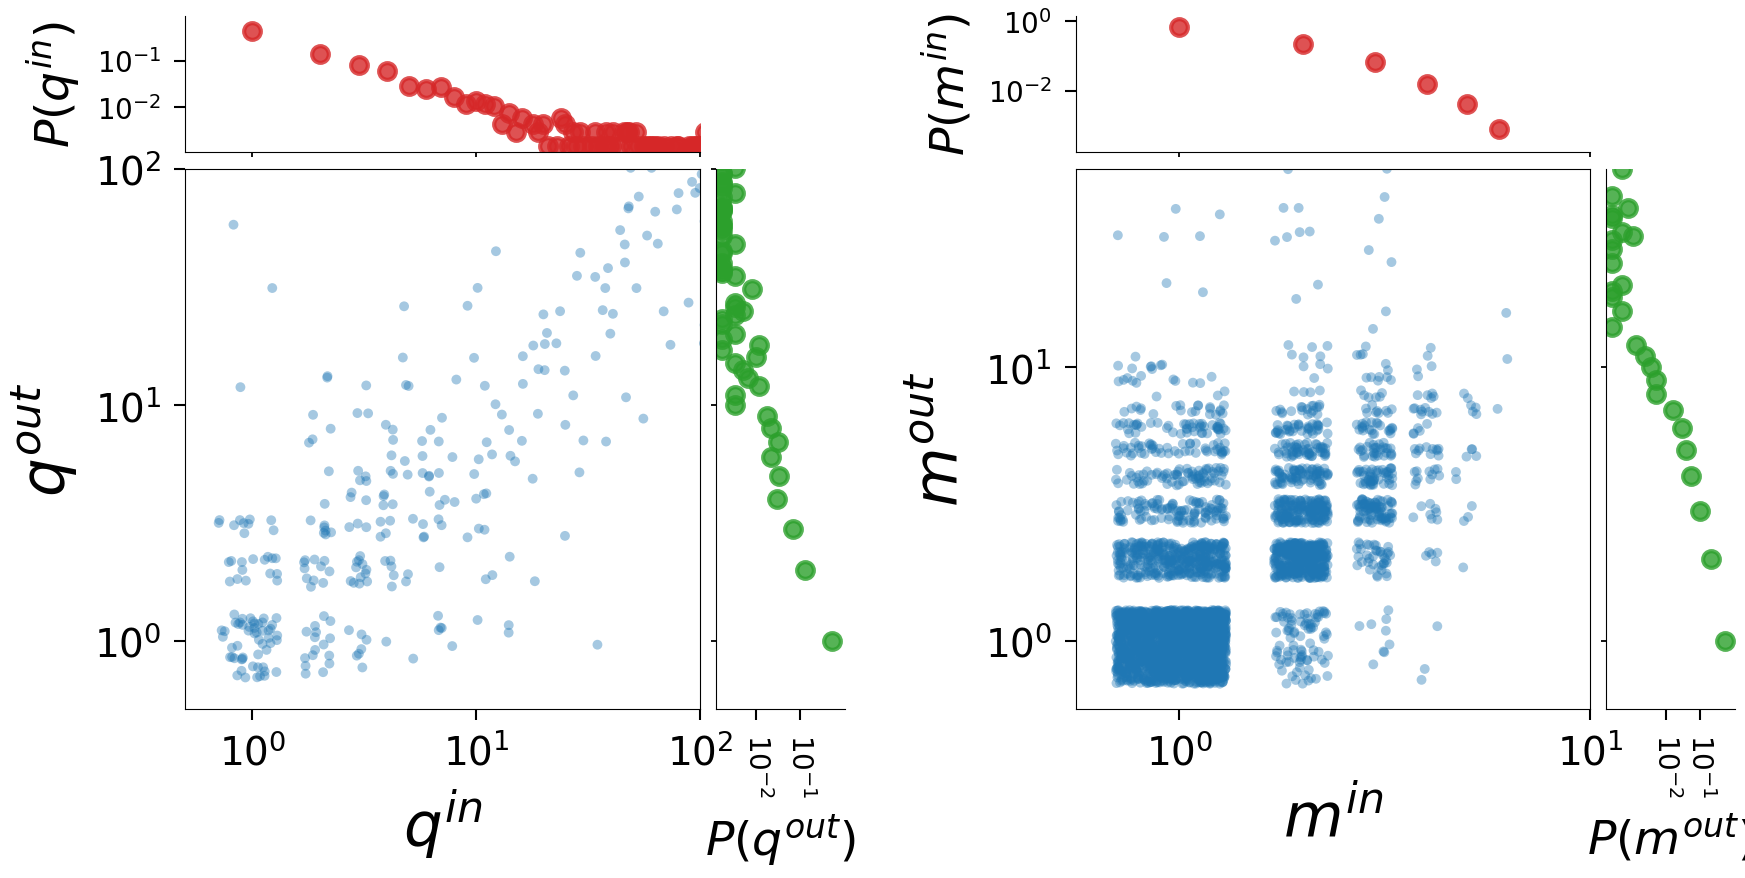

In [64]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
import numpy as np
import matplotlib.ticker as ticker 

def plot_joint_topology(filename='dnc.txt'):

    
    # ==========================================
    # 【参数设置区】 (全部可调参数都在这里)
    # ==========================================
    
    # 1. X 轴范围限制 (控制横向尾部留白)
    # 设为 None 则自动贴合数据最大值
    MANUAL_X_LIMIT_NODE = 100  
    MANUAL_X_LIMIT_HE   = 10
    
    # 2. 【新增】Y 轴范围限制 (控制纵向尾部留白)
    # 控制主图 Y 轴最大值，同时也控制右侧边缘图的高度
    MANUAL_Y_LIMIT_NODE = 100  # 左图 Y 轴最大值
    MANUAL_Y_LIMIT_HE   = None   # 右图 Y 轴最大值
    
    # 3. 右侧边缘图 (P(k)) 的刻度设置
    # 只显示 10^-1, 10^-2... 
    MANUAL_TICKS_NODE_P = [0.1, 0.01] 
    MANUAL_TICKS_HE_P   = [0.1, 0.01]       
    
    # 4. 缓冲系数 (防止球被截断)
    # 2.0 表示上限设置为最大数据点的 2 倍
    TOP_MARGIN_FACTOR   = 2.0  # 顶部图向上扩 (防止上边球截断)
    RIGHT_MARGIN_FACTOR = 2.0  # 右侧图向右扩 (防止右边球截断)
    
    # ==========================================
    # 样式配置参数
    # ==========================================
    AXIS_LABEL_SIZE = 34    
    TICK_LABEL_SIZE = 28    
    MARGINAL_MARKER_SIZE = 12      
    MARGINAL_MARKER_EDGE_WIDTH = 3 
    MAIN_SCATTER_SIZE = 50 
    
    # ==========================
    # 2. 数据解析
    # ==========================
    he_in_cards = []
    he_out_cards = []
    node_in_degree = defaultdict(int)
    node_out_degree = defaultdict(int)
    
    try:
        with open(filename, 'r') as f:
            f.readline() 
            while True:
                card_line = f.readline()
                while card_line and not card_line.strip():
                    card_line = f.readline()
                if not card_line: break
                
                try:
                    c_in, c_out = map(int, card_line.strip().split())
                    he_in_cards.append(c_in)
                    he_out_cards.append(c_out)
                except ValueError: continue

                if c_in > 0:
                    try:
                        nodes = list(map(int, f.readline().strip().split()))
                        for n in nodes: node_out_degree[n] += 1
                    except ValueError: pass
                elif c_in == 0: pass

                if c_out > 0:
                    try:
                        nodes = list(map(int, f.readline().strip().split()))
                        for n in nodes: node_in_degree[n] += 1
                    except ValueError: pass
                elif c_out == 0: pass

    except Exception as e:
        print(f"读取错误: {e}")
        return

    # ==========================
    # 3. 数据准备
    # ==========================
    all_nodes = set(node_in_degree.keys()) | set(node_out_degree.keys())
    x_node = np.array([node_in_degree[n] for n in all_nodes])
    y_node = np.array([node_out_degree[n] for n in all_nodes])
    
    x_he = np.array(he_in_cards)
    y_he = np.array(he_out_cards)

    def get_pdf_xy(data):
        if len(data) == 0: return [], []
        counts = Counter(data)
        x = sorted(counts.keys())
        y = [counts[k]/sum(counts.values()) for k in x]
        return np.array(x), np.array(y)

    # ==========================
    # 4. 绘图核心函数
    # ==========================
    def create_joint_plot(fig, outer_grid_pos, x_data, y_data, title, xlabel, ylabel, 
                          manual_limit_x=None, manual_limit_y=None, manual_ticks_p=None):
        gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_grid_pos, 
                                              width_ratios=[4, 1], height_ratios=[1, 4],
                                              wspace=0.05, hspace=0.05)

        ax_main = fig.add_subplot(gs[1, 0])
        ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

        valid_x = x_data[x_data > 0]
        valid_y = y_data[y_data > 0]
            
        # --- A. 中心散点图 ---
        jitter = 0.3
        x_j = x_data + np.random.uniform(-jitter, jitter, size=len(x_data))
        y_j = y_data + np.random.uniform(-jitter, jitter, size=len(y_data))
        mask = (x_data > 0) & (y_data > 0)
        
        ax_main.scatter(x_j[mask], y_j[mask], alpha=0.4, s=MAIN_SCATTER_SIZE, 
                        color='#1f77b4', edgecolors='none')
        
        ax_main.set_xscale('log')
        ax_main.set_yscale('log')
        
        # 1. 应用手动 X 轴 limit
        if manual_limit_x is not None:
            ax_main.set_xlim(right=manual_limit_x)
        else:
            if len(valid_x) > 0:
                ax_main.set_xlim(right=valid_x.max())
                
        # 2. 【关键修改】应用手动 Y 轴 limit
        if manual_limit_y is not None:
            ax_main.set_ylim(top=manual_limit_y)
        else:
            if len(valid_y) > 0:
                ax_main.set_ylim(top=valid_y.max())

        ax_main.set_xlabel(xlabel, fontsize=44, labelpad=10)
        ax_main.set_ylabel(ylabel, fontsize=44, labelpad=10)
        ax_main.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE, length=8, width=1.5)
        ax_main.tick_params(axis='both', which='minor', length=4, width=1)
        ax_main.minorticks_off()

        label_content_x = xlabel.replace('$', '')
        label_content_y = ylabel.replace('$', '')
        
        # 顶部图显示的是 X 轴变量的分布
        label_top_y   = r"$P(" + label_content_x + r")$" 
        # 右侧图显示的是 Y 轴变量的分布
        label_right_x = r"$P(" + label_content_y + r")$"
        
        # --- B. 顶部边缘分布 ---
        dist_x, dist_y = get_pdf_xy(valid_x)
        ax_top.loglog(dist_x, dist_y, 'o', 
                      markersize=MARGINAL_MARKER_SIZE, 
                      markeredgewidth=MARGINAL_MARKER_EDGE_WIDTH,
                      color='#d62728', alpha=0.8)
        
        if len(dist_y) > 0:
            max_prob = dist_y.max()
            ax_top.set_ylim(top=max_prob * TOP_MARGIN_FACTOR)
        
        ax_top.set_ylabel(label_top_y, fontsize=AXIS_LABEL_SIZE, labelpad=10)
        ax_top.grid(False)
        plt.setp(ax_top.get_xticklabels(), visible=False)
        ax_top.spines['top'].set_visible(False)
        ax_top.spines['right'].set_visible(False)
        ax_top.tick_params(axis='y', which='major', labelsize=20, length=8, width=1.5)
        ax_top.minorticks_off()

        # --- C. 右侧边缘分布 ---
        dist_x_r, dist_y_r = get_pdf_xy(valid_y)
        
        ax_right.loglog(dist_y_r, dist_x_r, 'o', 
                        markersize=MARGINAL_MARKER_SIZE,
                        markeredgewidth=MARGINAL_MARKER_EDGE_WIDTH,
                        color='#2ca02c', alpha=0.8)
        
        if len(dist_y_r) > 0: 
            max_prob_right = dist_y_r.max()
            ax_right.set_xlim(right=max_prob_right * RIGHT_MARGIN_FACTOR)

        ax_right.set_xlabel(label_right_x, fontsize=AXIS_LABEL_SIZE, labelpad=10)
        ax_right.grid(False)
        plt.setp(ax_right.get_yticklabels(), visible=False)
        ax_right.spines['top'].set_visible(False)
        ax_right.spines['right'].set_visible(False)
        
        if manual_ticks_p is not None:
            ax_right.set_xticks(manual_ticks_p)
            ax_right.get_xaxis().set_major_formatter(ticker.LogFormatterMathtext())
        
        ax_right.tick_params(axis='x', which='major', labelsize=20, 
                             length=8, width=1.5, rotation=270)
        ax_right.minorticks_off()

    # ==========================
    # 5. 构建画布
    # ==========================
    fig = plt.figure(figsize=(20, 9))
    outer_grid = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    create_joint_plot(fig, outer_grid[0], x_node, y_node, 
                      "Node Correlations", 
                      r"$q^{in}$", r"$q^{out}$",
                      manual_limit_x=MANUAL_X_LIMIT_NODE,
                      manual_limit_y=MANUAL_Y_LIMIT_NODE, # 传入 Y 限制
                      manual_ticks_p=MANUAL_TICKS_NODE_P) 

    create_joint_plot(fig, outer_grid[1], x_he, y_he, 
                      "Hyperedge Correlations", 
                      r"$m^{in}$", r"$m^{out}$",
                      manual_limit_x=MANUAL_X_LIMIT_HE,
                      manual_limit_y=MANUAL_Y_LIMIT_HE,   # 传入 Y 限制
                      manual_ticks_p=MANUAL_TICKS_HE_P)

    plt.savefig('dnc_joint_topology.svg', bbox_inches='tight')
    print("Plot saved as ijo_joint_topology.svg")

# 运行绘图
plot_joint_topology()

Plot saved as ijo_joint_topology.svg


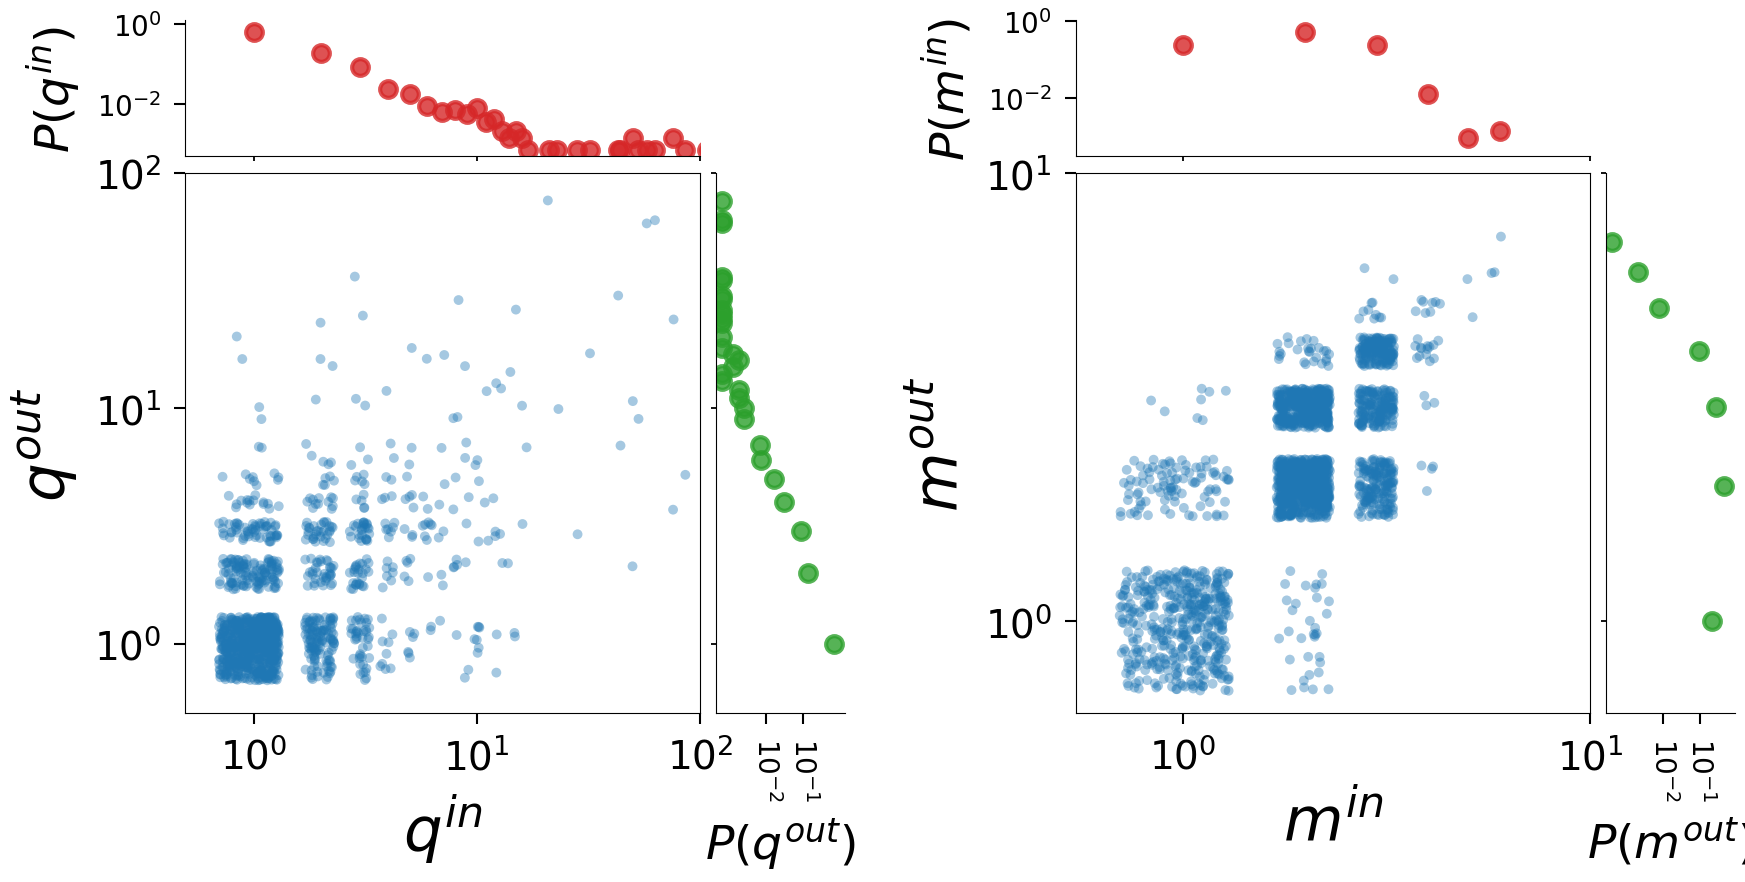

In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
import numpy as np
import matplotlib.ticker as ticker 

def plot_joint_topology(filename='ijo1366_hypergraph.txt'):
    """
    生成带边缘分布的联合相关性图 (Joint Plot with Marginals).
    修改版 (Full Control):
    1. 【新增】手动控制 Y 轴最大值 (MANUAL_Y_LIMIT)，即右边缘分布的范围。
    2. 包含之前所有修复：手动 X 轴、手动刻度、防止球被截断 (Margins)。
    """
    
    # ==========================================
    # 【参数设置区】 (全部可调参数都在这里)
    # ==========================================
    
    # 1. X 轴范围限制 (控制横向尾部留白)
    # 设为 None 则自动贴合数据最大值
    MANUAL_X_LIMIT_NODE = 100  
    MANUAL_X_LIMIT_HE   = 10
    
    # 2. 【新增】Y 轴范围限制 (控制纵向尾部留白)
    # 控制主图 Y 轴最大值，同时也控制右侧边缘图的高度
    MANUAL_Y_LIMIT_NODE = 100  # 左图 Y 轴最大值
    MANUAL_Y_LIMIT_HE   = 10   # 右图 Y 轴最大值
    
    # 3. 右侧边缘图 (P(k)) 的刻度设置
    # 只显示 10^-1, 10^-2... 
    MANUAL_TICKS_NODE_P = [0.1, 0.01] 
    MANUAL_TICKS_HE_P   = [0.1, 0.01]       
    
    # 4. 缓冲系数 (防止球被截断)
    # 2.0 表示上限设置为最大数据点的 2 倍
    TOP_MARGIN_FACTOR   = 2.0  # 顶部图向上扩 (防止上边球截断)
    RIGHT_MARGIN_FACTOR = 2.0  # 右侧图向右扩 (防止右边球截断)
    
    # ==========================================
    # 样式配置参数
    # ==========================================
    AXIS_LABEL_SIZE = 34    
    TICK_LABEL_SIZE = 28    
    MARGINAL_MARKER_SIZE = 12      
    MARGINAL_MARKER_EDGE_WIDTH = 3 
    MAIN_SCATTER_SIZE = 50 
    
    # ==========================
    # 2. 数据解析
    # ==========================
    he_in_cards = []
    he_out_cards = []
    node_in_degree = defaultdict(int)
    node_out_degree = defaultdict(int)
    
    try:
        with open(filename, 'r') as f:
            f.readline() 
            while True:
                card_line = f.readline()
                while card_line and not card_line.strip():
                    card_line = f.readline()
                if not card_line: break
                
                try:
                    c_in, c_out = map(int, card_line.strip().split())
                    he_in_cards.append(c_in)
                    he_out_cards.append(c_out)
                except ValueError: continue

                if c_in > 0:
                    try:
                        nodes = list(map(int, f.readline().strip().split()))
                        for n in nodes: node_out_degree[n] += 1
                    except ValueError: pass
                elif c_in == 0: pass

                if c_out > 0:
                    try:
                        nodes = list(map(int, f.readline().strip().split()))
                        for n in nodes: node_in_degree[n] += 1
                    except ValueError: pass
                elif c_out == 0: pass

    except Exception as e:
        print(f"读取错误: {e}")
        return

    # ==========================
    # 3. 数据准备
    # ==========================
    all_nodes = set(node_in_degree.keys()) | set(node_out_degree.keys())
    x_node = np.array([node_in_degree[n] for n in all_nodes])
    y_node = np.array([node_out_degree[n] for n in all_nodes])
    
    x_he = np.array(he_in_cards)
    y_he = np.array(he_out_cards)

    def get_pdf_xy(data):
        if len(data) == 0: return [], []
        counts = Counter(data)
        x = sorted(counts.keys())
        y = [counts[k]/sum(counts.values()) for k in x]
        return np.array(x), np.array(y)

    # ==========================
    # 4. 绘图核心函数
    # ==========================
    def create_joint_plot(fig, outer_grid_pos, x_data, y_data, title, xlabel, ylabel, 
                          manual_limit_x=None, manual_limit_y=None, manual_ticks_p=None):
        gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_grid_pos, 
                                              width_ratios=[4, 1], height_ratios=[1, 4],
                                              wspace=0.05, hspace=0.05)

        ax_main = fig.add_subplot(gs[1, 0])
        ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

        valid_x = x_data[x_data > 0]
        valid_y = y_data[y_data > 0]
            
        # --- A. 中心散点图 ---
        jitter = 0.3
        x_j = x_data + np.random.uniform(-jitter, jitter, size=len(x_data))
        y_j = y_data + np.random.uniform(-jitter, jitter, size=len(y_data))
        mask = (x_data > 0) & (y_data > 0)
        
        ax_main.scatter(x_j[mask], y_j[mask], alpha=0.4, s=MAIN_SCATTER_SIZE, 
                        color='#1f77b4', edgecolors='none')
        
        ax_main.set_xscale('log')
        ax_main.set_yscale('log')
        
        # 1. 应用手动 X 轴 limit
        if manual_limit_x is not None:
            ax_main.set_xlim(right=manual_limit_x)
        else:
            if len(valid_x) > 0:
                ax_main.set_xlim(right=valid_x.max())
                
        # 2. 【关键修改】应用手动 Y 轴 limit
        if manual_limit_y is not None:
            ax_main.set_ylim(top=manual_limit_y)
        else:
            if len(valid_y) > 0:
                ax_main.set_ylim(top=valid_y.max())

        ax_main.set_xlabel(xlabel, fontsize=44, labelpad=10)
        ax_main.set_ylabel(ylabel, fontsize=44, labelpad=10)
        ax_main.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE, length=8, width=1.5)
        ax_main.tick_params(axis='both', which='minor', length=4, width=1)
        ax_main.minorticks_off()

        label_content_x = xlabel.replace('$', '')
        label_content_y = ylabel.replace('$', '')                
# 顶部图显示的是 X 轴变量的分布
        label_top_y   = r"$P(" + label_content_x + r")$"         
# 右侧图显示的是 Y 轴变量的分布
        label_right_x = r"$P(" + label_content_y + r")$"
        # --- B. 顶部边缘分布 ---
        dist_x, dist_y = get_pdf_xy(valid_x)
        ax_top.loglog(dist_x, dist_y, 'o', 
                      markersize=MARGINAL_MARKER_SIZE, 
                      markeredgewidth=MARGINAL_MARKER_EDGE_WIDTH,
                      color='#d62728', alpha=0.8)
        
        if len(dist_y) > 0:
            max_prob = dist_y.max()
            ax_top.set_ylim(top=max_prob * TOP_MARGIN_FACTOR)
        
        ax_top.set_ylabel(label_top_y, fontsize=AXIS_LABEL_SIZE, labelpad=10)
        ax_top.grid(False)
        plt.setp(ax_top.get_xticklabels(), visible=False)
        ax_top.spines['top'].set_visible(False)
        ax_top.spines['right'].set_visible(False)
        ax_top.tick_params(axis='y', which='major', labelsize=20, length=8, width=1.5)
        ax_top.minorticks_off()

        # --- C. 右侧边缘分布 ---
        dist_x_r, dist_y_r = get_pdf_xy(valid_y)
        
        ax_right.loglog(dist_y_r, dist_x_r, 'o', 
                        markersize=MARGINAL_MARKER_SIZE,
                        markeredgewidth=MARGINAL_MARKER_EDGE_WIDTH,
                        color='#2ca02c', alpha=0.8)
        
        if len(dist_y_r) > 0: 
            max_prob_right = dist_y_r.max()
            ax_right.set_xlim(right=max_prob_right * RIGHT_MARGIN_FACTOR)

        ax_right.set_xlabel(label_right_x, fontsize=AXIS_LABEL_SIZE, labelpad=10)
        ax_right.grid(False)
        plt.setp(ax_right.get_yticklabels(), visible=False)
        ax_right.spines['top'].set_visible(False)
        ax_right.spines['right'].set_visible(False)
        
        if manual_ticks_p is not None:
            ax_right.set_xticks(manual_ticks_p)
            ax_right.get_xaxis().set_major_formatter(ticker.LogFormatterMathtext())
        
        ax_right.tick_params(axis='x', which='major', labelsize=20, 
                             length=8, width=1.5, rotation=270)
        ax_right.minorticks_off()

    # ==========================
    # 5. 构建画布
    # ==========================
    fig = plt.figure(figsize=(20, 9))
    outer_grid = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    create_joint_plot(fig, outer_grid[0], x_node, y_node, 
                      "Node Correlations", 
                      r"$q^{in}$", r"$q^{out}$",
                      manual_limit_x=MANUAL_X_LIMIT_NODE,
                      manual_limit_y=MANUAL_Y_LIMIT_NODE, # 传入 Y 限制
                      manual_ticks_p=MANUAL_TICKS_NODE_P) 

    create_joint_plot(fig, outer_grid[1], x_he, y_he, 
                      "Hyperedge Correlations", 
                      r"$m^{in}$", r"$m^{out}$",
                      manual_limit_x=MANUAL_X_LIMIT_HE,
                      manual_limit_y=MANUAL_Y_LIMIT_HE,   # 传入 Y 限制
                      manual_ticks_p=MANUAL_TICKS_HE_P)

    plt.savefig('ijo_joint_topology.svg', bbox_inches='tight')
    print("Plot saved as ijo_joint_topology.svg")

# 运行绘图
plot_joint_topology()

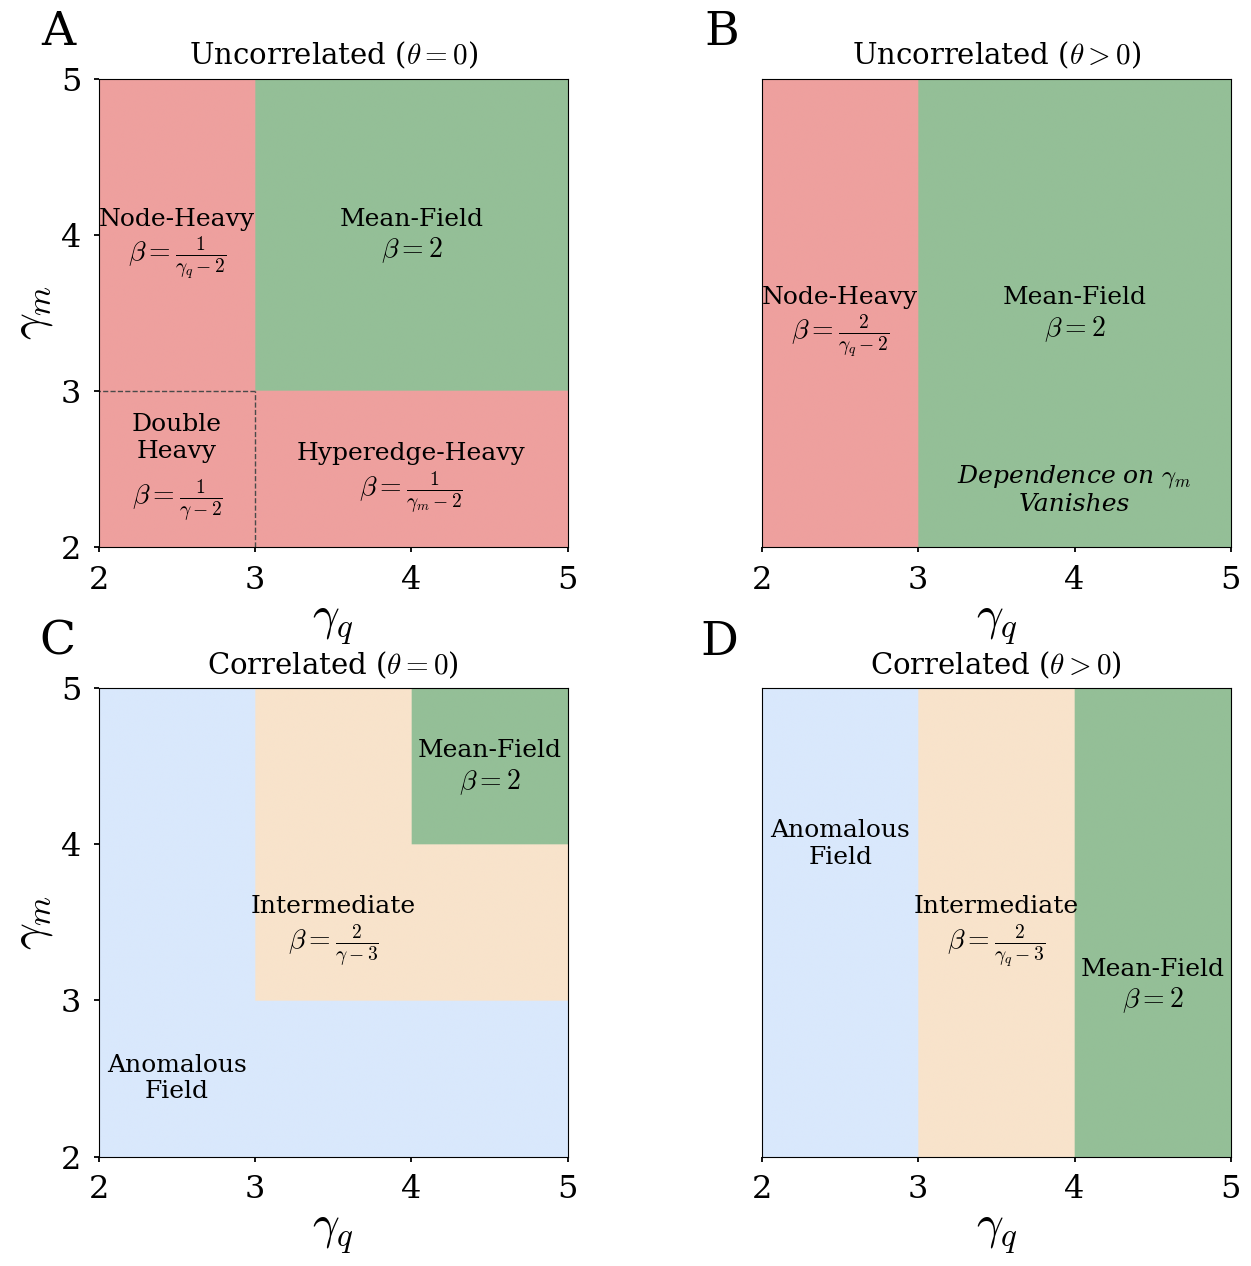

In [145]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

def plot_custom_pastel_phase_diagram():
    # 创建 2x2 的子图
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    plt.subplots_adjust(wspace=0.15, hspace=0.3)
    
    # Grid setup
    x = np.linspace(2.0, 5.0, 600)
    y = np.linspace(2.0, 5.0, 600)
    X, Y = np.meshgrid(x, y)
    
    # 刻度设置
    full_ticks = [2.0, 3.0, 4.0, 5.0]
    
    # --- 自定义颜色 (从图片近似提取) ---
    color_break = '#d9e8fc'
    color_break = '#d9e8fc' 
    color_inter = '#eea09e' 
    color_mf = '#94bf97' 
    color_double = '#f8e3cb' 
    eq_font_size = 20
    tick_size = 23
    label_size = 34
    font_size = 18
    title_size = 21
    boundary_style = {'color': '#4A4A4A', 'linestyle': '--', 'linewidth': 1}
    
    rgb_mf = mcolors.hex2color(color_mf)
    rgb_q = mcolors.hex2color(color_inter)
    rgb_m = mcolors.hex2color(color_inter) 
    rgb_double = mcolors.hex2color(color_break) 
    rgb_break = mcolors.hex2color(color_double) 

    # =======================================================
    # Row 1: Uncorrelated Case
    # =======================================================
    
    # --- Panel A: Uncorrelated, No Anchors (Top-Left) ---
    ax = axes[0, 0]
    mf = (X > 3) & (Y > 3)
    q_heavy = (X < 3) & (Y > 3)
    m_heavy = (X > 3) & (Y < 3)
    double_heavy = (X < 3) & (Y < 3)
    
    img = np.ones((*X.shape, 3)) 
    
    ax.plot([3, 2], [3, 3], **boundary_style)
    ax.plot([3, 3], [2, 3], **boundary_style)

    img[mf] = rgb_mf
    img[q_heavy] = rgb_q
    img[m_heavy] = rgb_m
    img[double_heavy] = rgb_q 
    
    ax.imshow(img, extent=(2, 5, 2, 5), origin='lower')
    
    # --- Modified Text Plotting A ---
    # Mean-Field
    ax.text(4.0, 4.1, r'Mean-Field', ha='center', va='center', fontsize=font_size)
    ax.text(4.0, 3.9, r'$\beta=2$', ha='center', va='center', fontsize=eq_font_size)
    
    # Node-Heavy
    ax.text(2.5, 4.1, r'Node-Heavy', ha='center', va='center', fontsize=font_size)
    ax.text(2.5, 3.85, r'$\beta = \frac{1}{\gamma_q-2}$', ha='center', va='center', fontsize=eq_font_size)
    
    # Edge-Heavy
    ax.text(4.0, 2.6, r'Hyperedge-Heavy', ha='center', va='center', fontsize=font_size)
    ax.text(4.0, 2.35, r'$\beta = \frac{1}{\gamma_m-2}$', ha='center', va='center', fontsize=eq_font_size)
    
    # Double Heavy
    ax.text(2.5, 2.7, r'Double' + '\n' + 'Heavy', ha='center', va='center', fontsize=font_size)
    ax.text(2.5, 2.3, r'$\beta = \frac{1}{\gamma-2}$', ha='center', va='center', fontsize=eq_font_size)
    
    ax.set_title(r'Uncorrelated ($\theta=0$)', fontsize=title_size, pad=10)
    ax.set_ylabel(r'$\gamma_m$', fontsize=label_size)
    ax.set_xticks(full_ticks)
    ax.set_yticks(full_ticks)
    ax.tick_params(labelsize=tick_size)
    ax.set_xlabel(r'$\gamma_q$', fontsize=label_size)

    # --- Panel B: Uncorrelated, With Anchors (Top-Right) ---
    ax = axes[0, 1]
    mf = (X > 3)
    node_heavy = (X < 3)
    
    img = np.ones((*X.shape, 3))
    img[mf] = rgb_mf
    img[node_heavy] = rgb_q
    
    ax.imshow(img, extent=(2, 5, 2, 5), origin='lower')
    
    # --- Modified Text Plotting B ---
    # Mean-Field
    ax.text(4.0, 3.6, r'Mean-Field', ha='center', va='center', fontsize=font_size)
    ax.text(4.0, 3.4, r'$\beta=2$', ha='center', va='center', fontsize=eq_font_size)
    
    # Node-Heavy
    ax.text(2.5, 3.6, r'Node-Heavy', ha='center', va='center', fontsize=font_size)
    ax.text(2.5, 3.35, r'$\beta = \frac{2}{\gamma_q-2}$', ha='center', va='center', fontsize=eq_font_size)
    
    # Dependence text (Keep as is, just ensure size is ok)
    ax.text(4.0, 2.2, r'Dependence on $\gamma_m$'+'\n'+r'Vanishes', ha='center', va='bottom', fontsize=font_size, fontstyle='italic')
    
    ax.set_title(r'Uncorrelated ($\theta>0$)', fontsize=title_size, pad=10)
    ax.set_yticklabels([])
    ax.set_xticks(full_ticks)
    ax.set_yticks(full_ticks)
    ax.tick_params(labelsize=tick_size)
    ax.set_xlabel(r'$\gamma_q$', fontsize=label_size)
    ax.tick_params(axis='y', left=False)

    # =======================================================
    # Row 2: Correlated Case
    # =======================================================
    
    # --- Panel C: Correlated, No Anchors (Bottom-Left) ---
    ax = axes[1, 0]
    mf = (X > 4) & (Y > 4)
    inter = ((X < 4) | (Y < 4)) & ((X > 3) & (Y > 3))
    breakdown = (X < 3) | (Y < 3)
    
    img = np.ones((*X.shape, 3))
    img[mf] = rgb_mf
    img[inter] = rgb_break
    img[breakdown] = rgb_double 
    
    ax.imshow(img, extent=(2, 5, 2, 5), origin='lower')
    
    # --- Modified Text Plotting C ---
    # Mean-Field
    ax.text(4.5, 4.6, r'Mean-Field', ha='center', va='center', fontsize=font_size)
    ax.text(4.5, 4.4, r'$\beta=2$', ha='center', va='center', fontsize=eq_font_size)
    
    # Intermediate
    ax.text(3.5, 3.6, r'Intermediate', ha='center', va='center', fontsize=font_size)
    ax.text(3.5, 3.35, r'$\beta = \frac{2}{\gamma-3}$', ha='center', va='center', fontsize=eq_font_size)
    
    # Anomalous
    ax.text(2.5, 2.5, r'Anomalous' + '\n' +'Field', ha='center', va='center', fontsize=font_size)
    
    ax.set_title(r'Correlated ($\theta=0$)', fontsize=title_size, pad=10)
    ax.set_xlabel(r'$\gamma_q$', fontsize=label_size)
    ax.set_ylabel(r'$\gamma_m$', fontsize=label_size)
    ax.set_xticks(full_ticks)
    ax.set_yticks(full_ticks)
    ax.tick_params(labelsize=tick_size)

    # --- Panel D: Correlated, With Anchors (Bottom-Right) ---
    ax = axes[1, 1]
    mf = (X > 4)
    inter = (X < 4) & (X > 3)
    breakdown = (X < 3)
    
    img = np.ones((*X.shape, 3))
    img[mf] = rgb_mf
    img[inter] = rgb_break
    img[breakdown] = rgb_double
    
    ax.imshow(img, extent=(2, 5, 2, 5), origin='lower')
    
    # --- Modified Text Plotting D ---
    # Mean-Field
    ax.text(4.5, 3.2, r'Mean-Field', ha='center', va='center', fontsize=font_size)
    ax.text(4.5, 3., r'$\beta=2$', ha='center', va='center', fontsize=eq_font_size)
    
    # Intermediate
    ax.text(3.5, 3.6, r'Intermediate', ha='center', va='center', fontsize=font_size)
    ax.text(3.5, 3.35, r'$\beta = \frac{2}{\gamma_q-3}$', ha='center', va='center', fontsize=eq_font_size)
    
    # Anomalous
    ax.text(2.5, 4, r'Anomalous' + '\n' +'Field', ha='center', va='center', fontsize=font_size)
    
    ax.set_title(r'Correlated ($\theta>0$)', fontsize=title_size, pad=10)
    ax.set_xlabel(r'$\gamma_q$', fontsize=label_size)
    ax.set_yticklabels([])
    ax.set_xticks(full_ticks)
    ax.tick_params(labelsize=tick_size)
    ax.tick_params(axis='y', left=False)

    panel_labels = ['A', 'B', 'C', 'D']
    axes_flat = axes.flatten()
    for i, ax in enumerate(axes_flat):
        ax.text(-0.05, 1.05, panel_labels[i], transform=ax.transAxes, 
                fontsize=34, va='bottom', ha='right')
    
    plt.savefig('Parameter Space Plot.pdf', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_custom_pastel_phase_diagram()